# Beyond the P-Value: A Rigorous A/B Test with Confidence Intervals & Dose-Response Analysis

## Introduction

### Overview
This project analyzes a real-world marketing A/B test to determine whether an ad campaign
drove meaningfully higher conversions compared to a neutral public service announcement (PSA)
control group. Rather than stopping at a simple p-value, this analysis takes a more complete
approach — including confidence interval visualization, a chi-square cross-check, and a
dose-response analysis examining how ad exposure level influences conversion likelihood.

### Business Question
**Did the ad campaign work, and if so, how should it inform future campaign strategy?**

### Dataset
- **Source:** Marketing A/B Testing dataset by Faviovazquez (Kaggle)
- **Size:** ~588,000 users
- **Groups:** Ad group (treatment) vs. PSA group (control)
- **Primary metric:** Conversion rate (proportion of users who converted)

### Methodology
1. **Sanity check** — Sample ratio mismatch test to validate the experiment setup
2. **Statistical testing** — Two-proportion z-test and chi-square cross-check
3. **Confidence intervals** — 95% CIs computed and visualized for both groups
4. **Dose-response analysis** — Conversion rate examined across ad exposure buckets
5. **Temporal segmentation** — Conversion patterns analyzed by day of week and hour of day
6. **Stakeholder recommendation** — Business conclusions drawn from all findings

### Tools
Python (pandas, scipy, statsmodels, matplotlib, seaborn)

## 1. Pace: Plan

In [1]:
# Import libraries and modules

# Data handling 
import numpy as np
import pandas as pd

# Statistical testing 
from scipy import stats
from scipy.stats import chi2_contingency, norm
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# Visualization 
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Display settings 
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

* **proportions_ztest**: returns z-stat and p-value
* **proportion_confint**: compute confidence intervals per group, for the CI visualization
* **chi2_contingency**: for cross-check — chi-square and the z-test should give consistent results
* **rcParams**: give matplotlib charts a cleaner look by removing the top and right spines

In [2]:
# Load data
df = pd.read_csv('/kaggle/input/datasets/faviovaz/marketing-ab-testing/marketing_AB.csv')

In [3]:
df.shape

(588101, 7)

In [4]:
# Data Dictionary

data_dict = {
'Column': [
'Unnamed: 0',
'user id',
'test group',
'converted',
'total ads',
'most ads day',
'most ads hour'
],
'Type': [
'int',
'int',
'string',
'boolean',
'int',
'string',
'int'
],
'Description': [
'Row index (can be dropped)',
'Unique identifier for each user',
'Group assignment — "ad" (saw advertisement) \nor "psa" (saw public service announcement)',
'Whether the user converted (True/False)',
'Total number of ads the user was shown',
'Day of the week the user saw the most ads',
'Hour of the day the user saw the most ads (0–23)'
],
'Role in Analysis': [
'Drop',
'Identifier',
'Independent variable (treatment vs control)',
'Dependent variable (primary metric)',
'Dose variable (exposure level)',
'Segmentation variable',
'Segmentation variable'
]
}

In [5]:
print(f"Variables - Data Dictionary")

pd.DataFrame(data_dict).style.set_properties(**{
'text-align': 'left',
'padding': '8px 12px',
'white-space': 'pre-wrap'
}).set_table_styles([
{'selector': 'th', 'props': [
('text-align', 'left'),
('padding', '8px 12px'),
('background-color', '#f2f2f2'),
('font-weight', 'bold')
]},
{'selector': 'td', 'props': [
('text-align', 'left'),
('vertical-align', 'top')
]},
{'selector': 'table', 'props': [
('border-collapse', 'collapse'),
('width', '100%')
]}
]).hide(axis='index')

Variables - Data Dictionary


Column,Type,Description,Role in Analysis
Unnamed: 0,int,Row index (can be dropped),Drop
user id,int,Unique identifier for each user,Identifier
test group,string,"Group assignment — ""ad"" (saw advertisement) or ""psa"" (saw public service announcement)",Independent variable (treatment vs control)
converted,boolean,Whether the user converted (True/False),Dependent variable (primary metric)
total ads,int,Total number of ads the user was shown,Dose variable (exposure level)
most ads day,string,Day of the week the user saw the most ads,Segmentation variable
most ads hour,int,Hour of the day the user saw the most ads (0–23),Segmentation variable


### Test Groups

This experiment compares two groups of users:

**Ad group (treatment):** Users who were shown the actual marketing advertisement.

**PSA group (control):** PSA stands for Public Service Announcement. Instead of seeing nothing, control group users were shown a neutral public service announcement in the same ad placement. This is a cleaner experimental design than a "no ad" control — both groups are exposed to content in the same format, which isolates the effect of the ad itself rather than the effect of simply seeing something versus nothing.

## 2. Pace: Analyze

### EDA

In [6]:
# Basic Info

print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Shape: (588101, 7)

Data Types:
Unnamed: 0        int64
user id           int64
test group       object
converted          bool
total ads         int64
most ads day     object
most ads hour     int64
dtype: object

Missing Values:
Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64


In [7]:
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [8]:
# Drop the index column and rename for cleanliness

df1 = df.drop(columns=['Unnamed: 0'])
df1.columns = ['user_id', 'test_group', 'converted', 'total_ads', 'most_ads_day', 'most_ads_hour']
df1.head()

,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [9]:
# Group Distribution

group_counts = df1['test_group'].value_counts().reset_index()
group_counts.columns = ['test_group', 'count']
group_counts['percentage'] = (group_counts['count'] / len(df1) * 100).round(2)
print(group_counts)

  test_group   count  percentage
0         ad  564577     96.0000
1        psa   23524      4.0000


In [10]:
# Conversion Rate by Group

conversion = df1.groupby('test_group')['converted'].agg(
users='count',
conversions='sum',
conversion_rate='mean'
).reset_index()
conversion['conversion_rate'] = (conversion['conversion_rate'] * 100).round(4)
print(conversion)

  test_group   users  conversions  conversion_rate
0         ad  564577        14423           2.5547
1        psa   23524          420           1.7854


In [11]:
#  Summary statistics for total ads exposure

print(df1.groupby('test_group')['total_ads'].describe().round(2))

                 count    mean     std    min    25%     50%     75%       max
test_group                                                                    
ad         564577.0000 24.8200 43.7500 1.0000 4.0000 13.0000 27.0000 2065.0000
psa         23524.0000 24.7600 42.8600 1.0000 4.0000 12.0000 26.0000  907.0000


In [12]:
# Conversion by Day and Hour 

print("Conversion rate by day:")
print(df1.groupby('most_ads_day')['converted'].mean().sort_values(ascending=False).round(4))

print("\nConversion rate by hour:")
print(df1.groupby('most_ads_hour')['converted'].mean().sort_values(ascending=False).round(4))

Conversion rate by day:
most_ads_day
Monday      0.0328
Tuesday     0.0298
Wednesday   0.0249
Sunday      0.0245
Friday      0.0222
Thursday    0.0216
Saturday    0.0211
Name: converted, dtype: float64

Conversion rate by hour:
most_ads_hour
16   0.0308
20   0.0298
15   0.0297
21   0.0289
17   0.0282
14   0.0281
18   0.0274
19   0.0267
22   0.0261
13   0.0247
12   0.0238
23   0.0227
6    0.0222
11   0.0221
10   0.0215
5    0.0209
8    0.0195
9    0.0192
0    0.0184
7    0.0181
4    0.0152
1    0.0129
3    0.0105
2    0.0073
Name: converted, dtype: float64


## Statistical Testing

The Sample Ratio Mismatch Check below shows how this dataset is notably imbalanced (~96% ad, ~4% psa). The split was intentional by the original experiment design, not a data quality issue.

In [13]:
# Sample Ratio Mismatch Check

ad_count = df1[df1['test_group'] == 'ad']['user_id'].count()
psa_count = df1[df1['test_group'] == 'psa']['user_id'].count()
total = ad_count + psa_count

expected_ad = total * 0.5
expected_psa = total * 0.5

chi2, p_srm = chi2_contingency([[ad_count, psa_count], [expected_ad, expected_psa]])[0:2]

print(f"Ad group: {ad_count:,} users ({ad_count/total*100:.1f}%)")
print(f"PSA group: {psa_count:,} users ({psa_count/total*100:.1f}%)")
print(f"\nSRM Chi-square p-value: {p_srm:.4f}")
print("⚠️ Sample ratio mismatch detected" if p_srm < 0.05 else "✓ No sample ratio mismatch")

Ad group: 564,577 users (96.0%)
PSA group: 23,524 users (4.0%)

SRM Chi-square p-value: 0.0000
⚠️ Sample ratio mismatch detected


### Absolute Lift vs Relative Lift

**Absolute lift** is the straightforward difference in conversion rates between the two groups. In business, it answers: *how many more users converted because of the ad?* Business teams use this number to estimate additional revenue or customer volume.:\
**Ad conversion rate − PSA conversion rate = absolute lift**

If the ad group converts at 2.5% and the PSA group at 2.0%, the absolute lift is **0.5 percentage points** — meaning the ad directly added 0.5% more conversions.

**Relative lift** expresses that same difference as a percentage of the baseline (PSA) rate. In business, it answers: *how much did the ad improve on what we would have gotten anyway?* This is useful for comparing campaigns across different products or time periods where baseline rates differ:\
**(Ad rate − PSA rate) / PSA rate = relative lift**

Using the same example, 0.5% / 2.0% = **25% relative lift** — meaning the ad improved conversions by 25% over the control group's baseline.

Both matter: absolute lift gives the real-world magnitude of the effect, while relative lift puts it in context of how low or high the baseline already is. A small absolute lift can still represent a large relative lift if the baseline rate is very low — which is common in marketing experiments. Reporting both gives a complete picture.

In [14]:
# Two-Proportion Z-Test

ad_users = df1[df1['test_group'] == 'ad']
psa_users = df1[df1['test_group'] == 'psa']

ad_conversions = ad_users['converted'].sum()
psa_conversions = psa_users['converted'].sum()
ad_total = len(ad_users)
psa_total = len(psa_users)

count = np.array([ad_conversions, psa_conversions])
nobs = np.array([ad_total, psa_total])

z_stat, p_value = proportions_ztest(count, nobs)

print(f"Ad conversion rate: {ad_conversions/ad_total*100:.4f}%")
print(f"PSA conversion rate: {psa_conversions/psa_total*100:.4f}%")
print(f"Absolute lift: {(ad_conversions/ad_total - psa_conversions/psa_total)*100:.4f}%")
print(f"Relative lift: {((ad_conversions/ad_total - psa_conversions/psa_total)/( psa_conversions/psa_total))*100:.2f}%")
print(f"\nZ-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print("\n✓ Statistically significant" if p_value < 0.05 else "✗ Not statistically significant")

Ad conversion rate: 2.5547%
PSA conversion rate: 1.7854%
Absolute lift: 0.7692%
Relative lift: 43.09%

Z-statistic: 7.3701
P-value: 0.0000

✓ Statistically significant


In [15]:
# Confidence Intervals (95%)

ad_ci = proportion_confint(ad_conversions, ad_total, alpha=0.05, method='normal')
psa_ci = proportion_confint(psa_conversions, psa_total, alpha=0.05, method='normal')

print(f"Ad group 95% CI: ({ad_ci[0]*100:.4f}%, {ad_ci[1]*100:.4f}%)")
print(f"PSA group 95% CI: ({psa_ci[0]*100:.4f}%, {psa_ci[1]*100:.4f}%)")

Ad group 95% CI: (2.5135%, 2.5958%)
PSA group 95% CI: (1.6162%, 1.9546%)


### Chi-Square Cross-Check

As a best practice, we cross-check our z-test result using a chi-square test of independence. Both tests are valid for comparing proportions between two groups, but they approach the question differently:
* the z-test directly compares conversion rates
* the chi-square test evaluates whether group membership (ad vs. PSA) and conversion outcome (True vs. False) are statistically independent of each other

When both tests agree, it strengthens confidence in the result. A disagreement between the two would be a signal to investigate further before drawing conclusions.

In [16]:
# Chi-Square Cross-Check

contingency_table = pd.crosstab(df1['test_group'], df1['converted'])
chi2_stat, p_chi2, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"P-value: {p_chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print("\nBoth tests agree ✓" if (p_value < 0.05) == (p_chi2 < 0.05) else "Tests disagree — investigate further")

Chi-square statistic: 54.0058
P-value: 0.0000
Degrees of freedom: 1

Both tests agree ✓


### Statistical Testing Results Summary

The two-proportion z-test reveals a statistically significant difference in conversion rates
between the ad and PSA groups (z = 7.37, p < 0.0001).

**Key findings:**
- The ad group converted at **2.55%** versus **1.79%** for the PSA control group
- This represents an **absolute lift of 0.77 percentage points** and a **relative lift of 43.09%** — meaning the ad improved conversions by over 43% compared to the baseline
- The 95% confidence intervals for both groups do not overlap (Ad: 2.51%–2.60%, PSA: 1.62%–1.95%), further confirming the effect is real and not due to chance
- A chi-square cross-check produced a consistent result (χ² = 54.01, p < 0.0001, df = 1), confirming both tests agree

The result is statistically significant at the 0.05 threshold. The ad campaign drove meaningfully
higher conversions than the PSA control, and the effect size is large enough to be of practical
business relevance.

## 3. Pace: Construct

## Visualizations

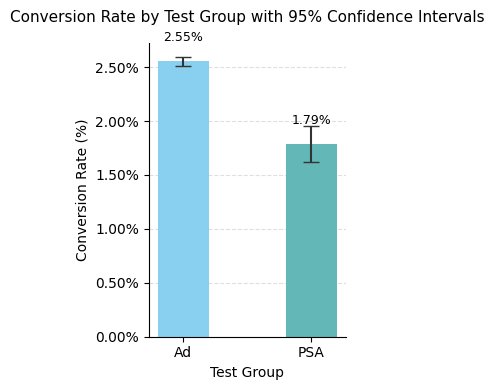

In [17]:
# Conversion Rate by Group

fig, ax = plt.subplots(figsize=(3, 4))

groups = ['Ad', 'PSA']
rates = [ad_conversions/ad_total*100, psa_conversions/psa_total*100]
ci_lower = [ad_ci[0]*100, psa_ci[0]*100]
ci_upper = [ad_ci[1]*100, psa_ci[1]*100]
errors = [
[rates[0]-ci_lower[0], rates[1]-ci_lower[1]],
[ci_upper[0]-rates[0], ci_upper[1]-rates[1]]
]

colors = ['#89CFF0', '#63B7B7']
bars = ax.bar(groups, rates, color=colors, width=0.4, zorder=2)
ax.errorbar(groups, rates, yerr=errors, fmt='none', color='#333333', capsize=6, linewidth=1.5, zorder=3)

for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.16,
            f'{rate:.2f}%', ha='center', va='bottom', fontsize=9)

ax.set_title('Conversion Rate by Test Group with 95% Confidence Intervals', fontsize=11, pad=15)
ax.set_ylabel('Conversion Rate (%)', fontsize=10)
ax.set_xlabel('Test Group', fontsize=10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=1)
plt.tight_layout()
plt.savefig('conversion_rate_by_group.png', dpi=150, bbox_inches='tight')
plt.show()

#### Conversion Rate by Test Group — Findings

The bar chart above displays the conversion rate for each group, with the percentage labels
showing the proportion of users in each group who converted.

- The **ad group converted at 2.55%** and the **PSA group at 1.79%**
- The small **error bars (⊤)** on top of each bar represent the **95% confidence interval** —
the range within which the true conversion rate is likely to fall if the experiment were
repeated. A narrower bar means more certainty; a wider bar means more uncertainty
- The ad group's confidence interval (2.51%–2.60%) and the PSA group's interval
(1.62%–1.95%) **do not overlap at all**, which visually confirms what the z-test told us
statistically: the difference between the two groups is real and not due to chance
- The ad group has a noticeably narrower error bar than the PSA group because it has
a much larger sample size (~96% of all users), giving us more precision on its true
conversion rate

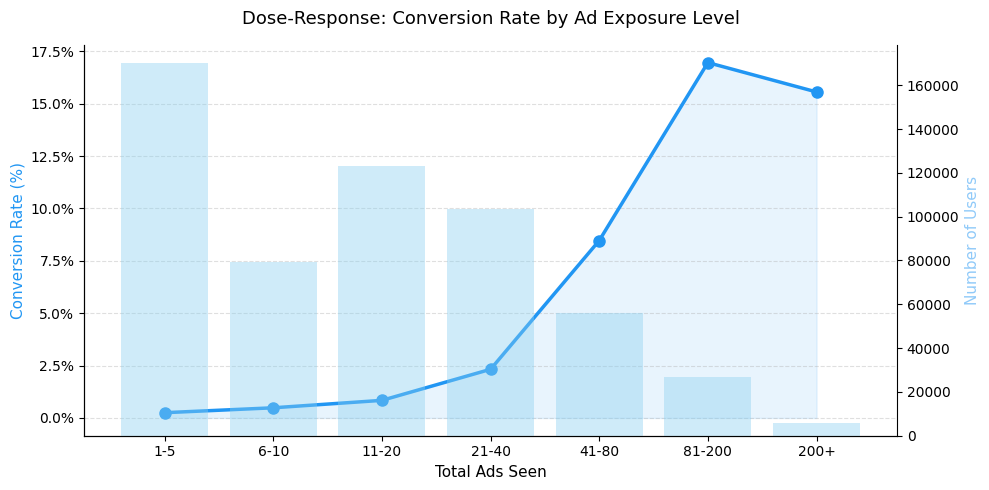

In [18]:
# Dose-Response Curve
ad_df = df1[df1['test_group'] == 'ad'].copy()
ad_df['ads_bucket'] = pd.cut(ad_df['total_ads'],
bins=[0,5,10,20,40,80,200,800],
labels=['1-5','6-10','11-20','21-40','41-80','81-200','200+'])

dose_response = ad_df.groupby('ads_bucket', observed=True)['converted'].agg(
users='count',
conversion_rate='mean'
).reset_index()
dose_response['conversion_rate'] = dose_response['conversion_rate'] * 100

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(dose_response['ads_bucket'], dose_response['conversion_rate'],
color='#2196F3', marker='o', linewidth=2.5, markersize=8, zorder=3)
ax1.fill_between(range(len(dose_response)), dose_response['conversion_rate'],
alpha=0.1, color='#2196F3')
ax1.set_xlabel('Total Ads Seen', fontsize=11)
ax1.set_ylabel('Conversion Rate (%)', fontsize=11, color='#2196F3')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.grid(axis='y', linestyle='--', alpha=0.4, zorder=1)

ax2 = ax1.twinx()
ax2.bar(dose_response['ads_bucket'], dose_response['users'],
color='#89CFF0', alpha=0.4, zorder=2)
ax2.set_ylabel('Number of Users', fontsize=11, color='#90CAF9')
ax2.spines['right'].set_visible(True)

ax1.set_title('Dose-Response: Conversion Rate by Ad Exposure Level', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('dose_response.png', dpi=150, bbox_inches='tight')
plt.show()

#### Dose-Response: Conversion Rate by Ad Exposure Level — Findings

The line chart above shows how conversion rate changes as users are exposed to more ads,
with the background bars showing the number of users in each exposure bucket.

- Users who saw very few ads (**1–5**) converted at under **0.5%** — close to the PSA
baseline — suggesting that minimal exposure is not enough to drive meaningful action
- Conversion rate rises gradually through the **6–10, 11–20, and 21–40** buckets,
indicating that repeated exposure builds familiarity and intent over time
- A sharp acceleration occurs between **41–80 ads (~8.5%)** and **81–200 ads (~17%)**,
suggesting a threshold effect where heavier exposure significantly increases the
likelihood of conversion
- Conversion rate slightly drops off at **200+ ads (~15.5%)**, which may be an early
signal of **ad fatigue** — where overexposure begins to diminish returns
- The user volume bars reveal that the **1–5 and 11–20 buckets contain the most users**,
while the **81–200 and 200+ buckets are very small in size** — meaning the highest
conversion rates are driven by a relatively small group of heavily exposed users

Overall, the data suggests that more ad exposure drives higher conversion up to a point,
with diminishing returns beginning around 200+ ads seen. However, since most users
fall in the low-exposure buckets, the average campaign conversion rate remains modest.


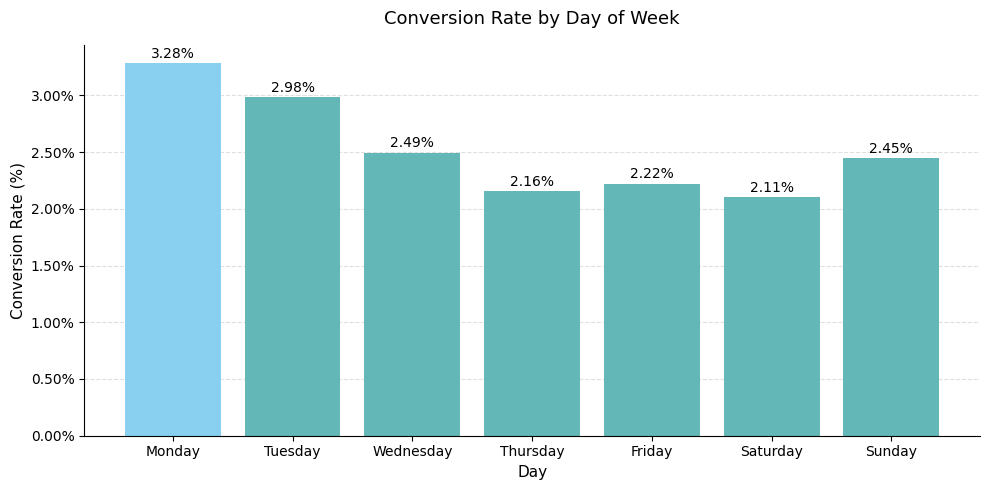

In [19]:
# Conversion Rate by Day of Week

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_conv = df1.groupby('most_ads_day')['converted'].mean().reindex(day_order) * 100

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#89CFF0' if v == day_conv.max() else '#63B7B7' for v in day_conv]
bars = ax.bar(day_conv.index, day_conv.values, color=colors, zorder=2)

for bar, val in zip(bars, day_conv.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=10)

ax.set_title('Conversion Rate by Day of Week', fontsize=13, pad=15)
ax.set_ylabel('Conversion Rate (%)', fontsize=11)
ax.set_xlabel('Day', fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=1)
plt.tight_layout()
plt.savefig('conversion_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

#### Conversion Rate by Day of Week — Findings

- **Monday has the highest conversion rate at 3.28%**, highlighted in blue, followed by
Tuesday at 2.98% — suggesting users are most receptive to the ad at the start of the
work week
- Conversion rates decline steadily through the week, reaching their lowest point on
**Saturday at 2.11%**
- Weekend conversion rates (Saturday 2.11%, Sunday 2.45%) are both below the weekly
average, indicating users may be less likely to convert when browsing casually on
weekends
- The gap between the best day (Monday 3.28%) and worst day (Saturday 2.11%)
represents over a full percentage point difference — meaningful enough to inform
ad scheduling decisions

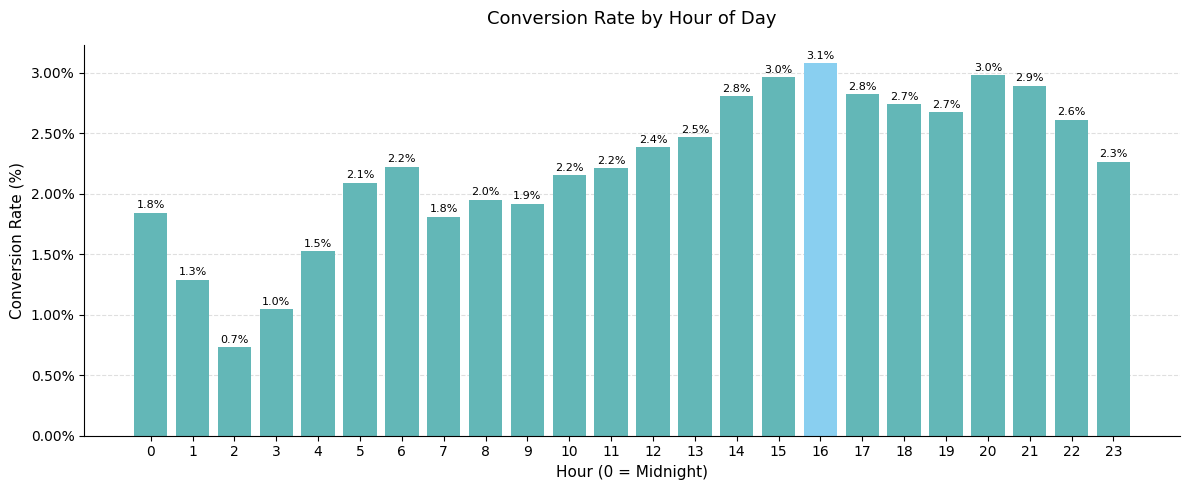

In [20]:
# Conversion Rate by Hour of Day

hour_conv = df1.groupby('most_ads_hour')['converted'].mean() * 100

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#89CFF0' if v == hour_conv.max() else '#63B7B7' for v in hour_conv]
bars = ax.bar(hour_conv.index, hour_conv.values, color=colors, zorder=2)

for bar, val in zip(bars, hour_conv.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_title('Conversion Rate by Hour of Day', fontsize=13, pad=15)
ax.set_ylabel('Conversion Rate (%)', fontsize=11)
ax.set_xlabel('Hour (0 = Midnight)', fontsize=11)
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=1)
plt.tight_layout()
plt.savefig('conversion_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

#### Conversion Rate by Hour of Day — Findings

- **4 PM (hour 16) has the highest conversion rate at 3.1%**, highlighted in blue,
suggesting users are most receptive to the ad during mid-afternoon hours
- Conversion rates are at their lowest in the early morning hours, bottoming out at
**2 AM (0.7%)**, which is expected as overall user activity is minimal overnight
- There is a clear **upward trend throughout the day** starting from the early morning
low, climbing steadily into the afternoon peak at 4 PM
- After 4 PM, conversion rates remain relatively strong through the evening
(**3.0% at 8 PM, 2.9% at 9 PM**) before gradually declining toward midnight
- The **5–6 AM window shows a small early morning spike (2.1%–2.2%)**, which may
reflect a segment of early-rising users checking their devices before work
- Combined with the day-of-week findings, the data suggests that **Monday afternoons
and evenings represent the optimal window** for ad delivery to maximize conversion

## 4. Pace: Execute

## Stakeholder Recommendation

### Should We Run the Ad? 
#### Yes — With Strategic Targeting

The data provides clear evidence that the ad campaign was effective. Users exposed to the
advertisement converted at **2.55%** compared to **1.79%** for the PSA control group,
representing a **43.09% relative lift** that is statistically significant (z = 7.37, p < 0.0001).
The result was confirmed by both a two-proportion z-test and a chi-square cross-check,
and the non-overlapping 95% confidence intervals leave little doubt that the effect is real.

However, the analysis reveals three strategic opportunities to make future campaigns
even more effective:

### 1. Optimize Ad Frequency
The dose-response analysis shows that conversion rate rises sharply with ad exposure,
peaking at **~17% for users who saw 81–200 ads** before slightly declining at 200+ ads.
The majority of users currently fall in the low-exposure buckets (1–20 ads) and never
reach the high-conversion threshold. **Increasing ad frequency for engaged users up to
the 81–200 range could meaningfully improve overall campaign conversion rates**, while
being mindful of the slight fatigue signal observed beyond 200 ads.

### 2. Prioritize Monday and Tuesday for Ad Delivery
Conversion rates are highest at the start of the work week — **Monday (3.28%)** and
**Tuesday (2.98%)** — and decline steadily through the weekend, bottoming out on
**Saturday (2.11%)**. Concentrating ad spend on weekdays, particularly Monday and
Tuesday, is likely to yield better returns than uniform weekly distribution.

### 3. Target Mid-Afternoon to Evening Hours
**4 PM (3.1%)** is the peak conversion hour, with strong performance continuing through
the evening (8 PM at 3.0%, 9 PM at 2.9%). Early morning hours (2–3 AM) show the
lowest conversion rates and should be deprioritized for ad delivery. Scheduling ads
to serve primarily between **2 PM and 10 PM** would align delivery with peak user
receptivity.

### Summary
| Finding | Recommendation |
|---|---|
| 43.09% relative lift vs PSA | Continue running the ad campaign |
| Peak conversion at 81–200 ad exposures | Increase frequency for engaged users |
| Monday highest converting day | Concentrate spend early in the week |
| 4 PM peak conversion hour | Schedule ads between 2 PM and 10 PM |

### Caveat
This dataset does not include revenue or cost data, so while the campaign clearly drives
higher conversion rates, a full ROI analysis would require layering in cost-per-impression
and revenue-per-conversion figures before making final budget recommendations.

## Acknowledgments

This analysis was developed with the assistance of Claude (Anthropic).